# Oasis Infobyte Internship – Data Analytics

## Level 1 – Task 1: EDA on Retail Sales Data

### Objective
To perform Exploratory Data Analysis (EDA) on retail sales data to identify sales patterns, customer behaviour trends, and actionable business insights.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from google.colab import files
uploaded = files.upload()


Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [30]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [31]:
print("Number od rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData type:")
print(df.dtypes)

Number od rows: 1000
Number of columns: 9

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data type:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [32]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [33]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [34]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)

datetime64[ns]


##  1. Dataset Overview
 The dataset contains 1,000 retail transactions and 9 columns.

 The dataset includes transaction details, customer demographics, product categories, quantity purchased, price per unit, and total transaction amount.

 The Data column was converted to datetime format for time-series analysis.

 Missing values and duplicate records are also checked during initial data inspection.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (2).csv


In [37]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [38]:
df['Date']=pd.to_datetime(df['Date'])
print(df['Date'].dtype)

datetime64[ns]


In [39]:
numeric_columns = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [40]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()
monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


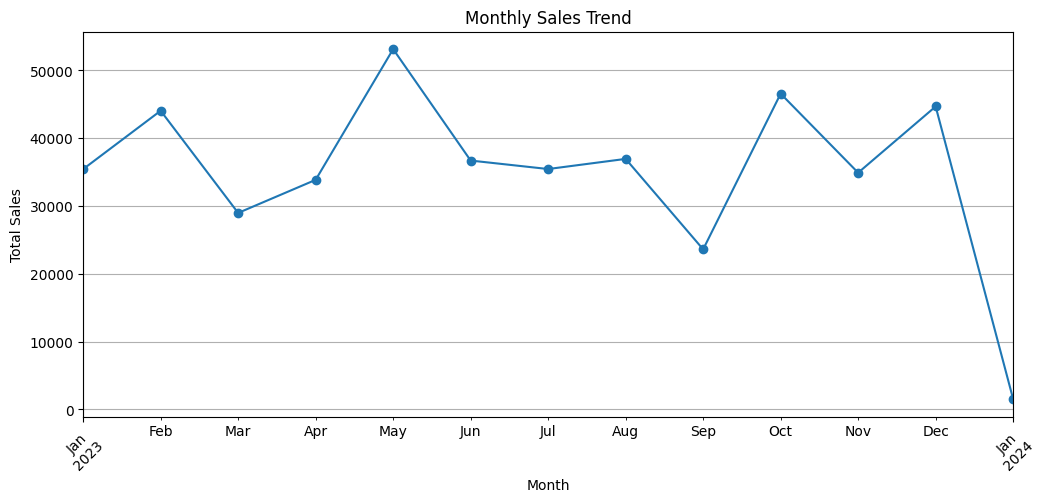

In [41]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The monthly sales trend shows significance variation in sales over the observed period. Sales are relatively high at the beginning of the period, followed by considerable fluctuations across the month. The sharp change near the end of the period indicates that sales performance was not consistent throughout the dataset.

In [42]:
quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

quarterly_sales

,Total Amount
Date,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


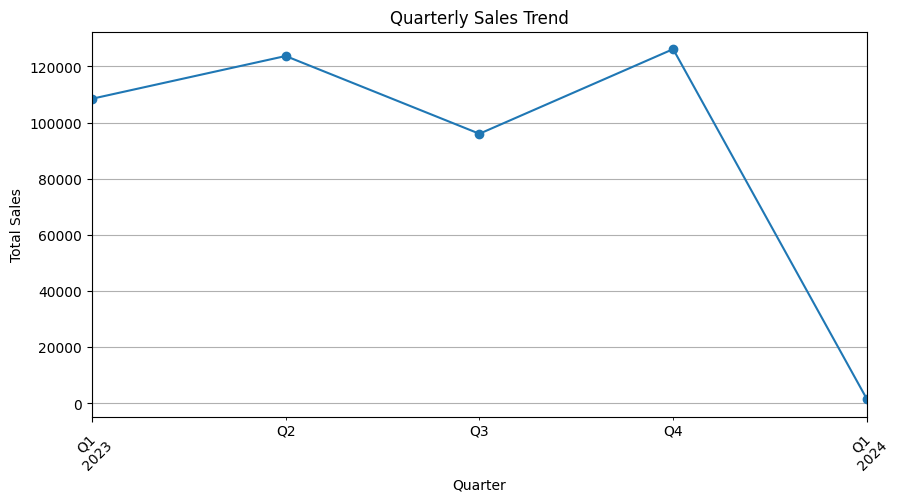

In [43]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The quarterly sales trend shows noticeable fluctuations in sales
performance. Sales increased from Q1 to Q2 2023, declined in Q3, and
reached the highest level in Q4 2023. A sharp decline is observed in
Q1 2024 compared with the previous quarter.

In [44]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


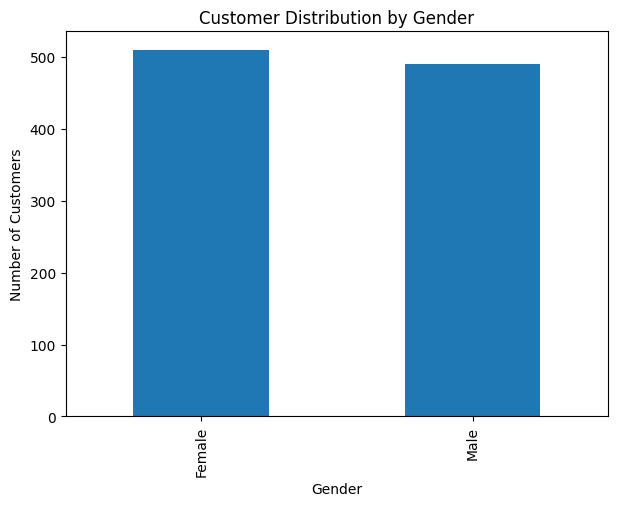

In [45]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The gender distribution shows that female customers are slightly higher
in number than male customers. However, the difference is relatively
small, indicating a fairly balanced customer base across the two gender
groups.

In [46]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=True
)

age_groups = df['Age Group'].value_counts().sort_index()

age_groups

,count
Age Group,
Under 18,21
18-25,148
26-35,205
36-45,202
46-55,229
56-65,195
65+,0


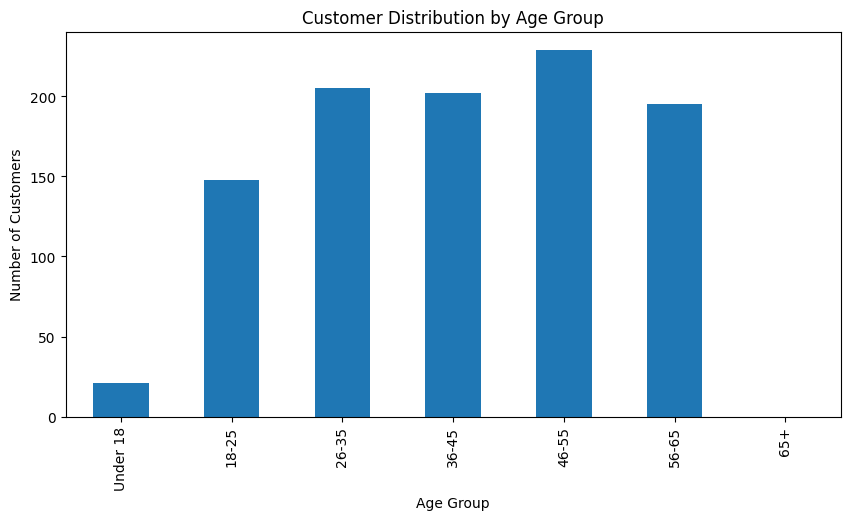

In [47]:
plt.figure(figsize=(10, 5))

age_groups.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The age-group distribution shows that customers are concentrated mainly
between 26 and 65 years. The 46-55 age group has the highest number of
customers, while the Under 18 group has very few customers. There are no
customers in the 65+ age group in this dataset.

In [48]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(category_sales)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


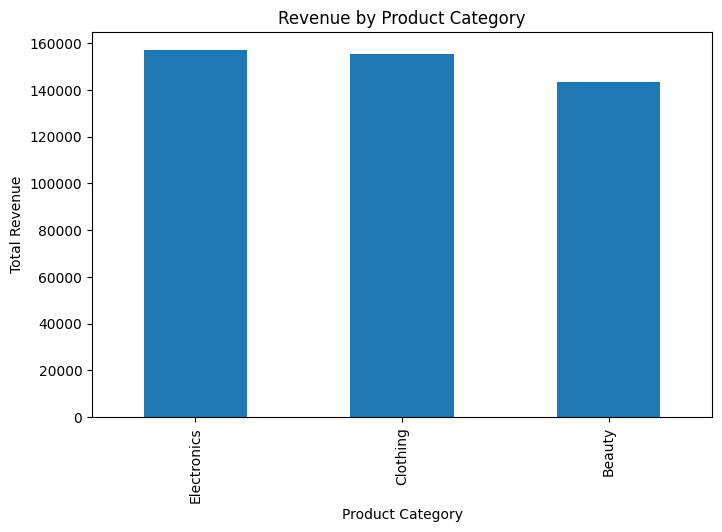

In [49]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.show()

### Observation

Electronics generates the highest revenue among the three product
categories, followed closely by Clothing. Beauty has the lowest revenue.
However, the revenue difference between the categories is relatively
small, indicating that all three categories contribute significantly to
overall sales.

In [50]:
category_quantity = df.groupby(
    'Product Category'
)['Quantity'].sum().sort_values(ascending=False)

print(category_quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


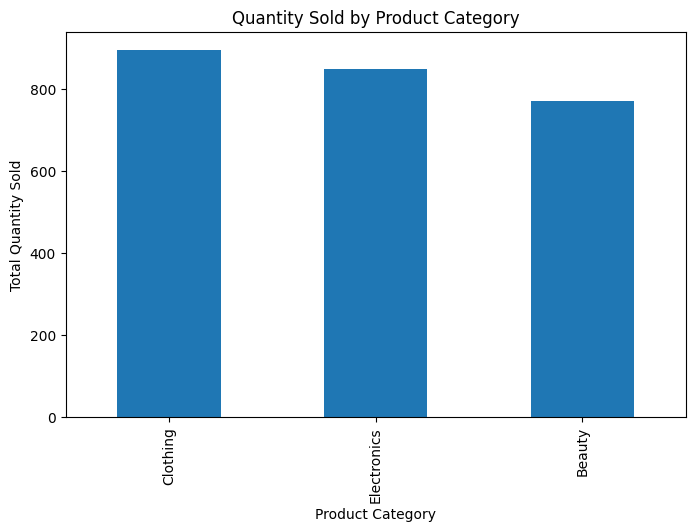

In [51]:
plt.figure(figsize=(8, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')

plt.show()

### Observation

Clothing has the highest quantity of units sold, followed by Electronics.
Beauty has the lowest quantity sold among the three categories. This
indicates that Clothing has the highest product demand by volume, while
Beauty has comparatively lower unit sales.

In [52]:
correlation = df[numeric_columns].corr()

correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


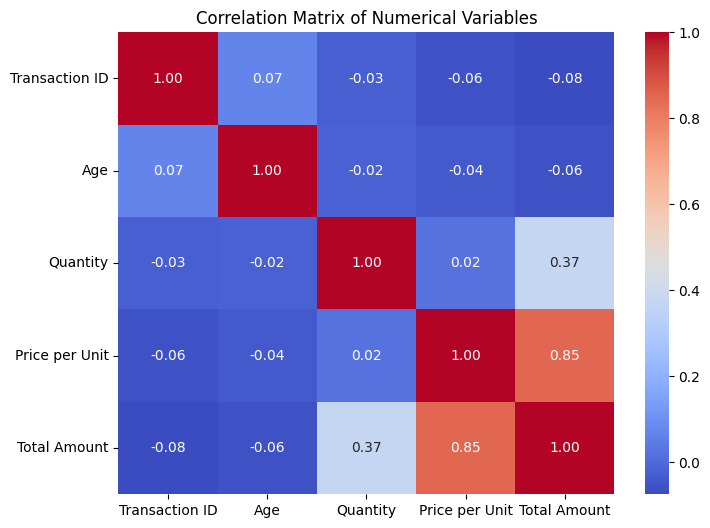

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

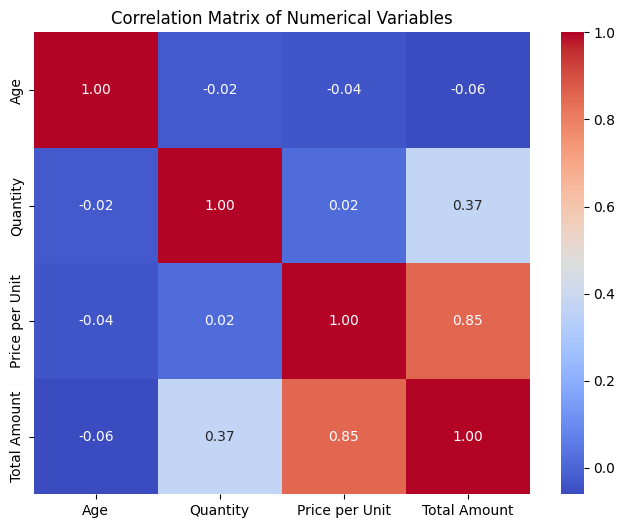

In [54]:
meaningful_numeric = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation = df[meaningful_numeric].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

### Observation

Price per Unit and Total Amount show a strong positive correlation of
0.85, indicating that higher-priced items generally contribute to higher
transaction amounts. Quantity has a moderate positive correlation of
0.37 with Total Amount. Age has a very weak negative correlation with
Total Amount (-0.06), suggesting that customer age has little linear
relationship with transaction value.

In [55]:
age_group_sales = df.groupby(
    'Age Group',
    observed=True
)['Total Amount'].mean()

age_group_sales

,Total Amount
Age Group,
Under 18,534.047619
18-25,495.506757
26-35,480.390244
36-45,454.801980
46-55,439.694323
56-65,412.358974


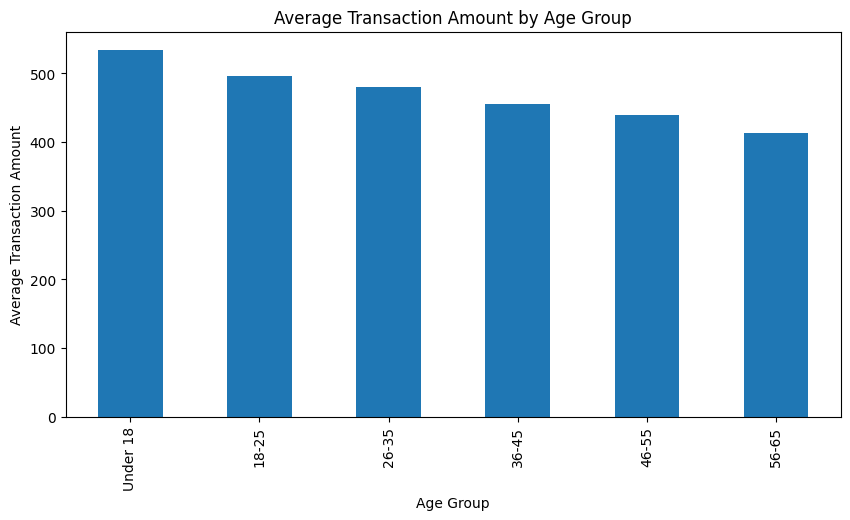

In [56]:
plt.figure(figsize=(10, 5))

age_group_sales.plot(kind='bar')

plt.title('Average Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount')

plt.show()

The average transaction amount is highest for customers under 18 and gradually decreases across the older age groups. This indicates that younger customers tend to have higher average transaction values, while older age groups have comparatively lower average spending per transaction.

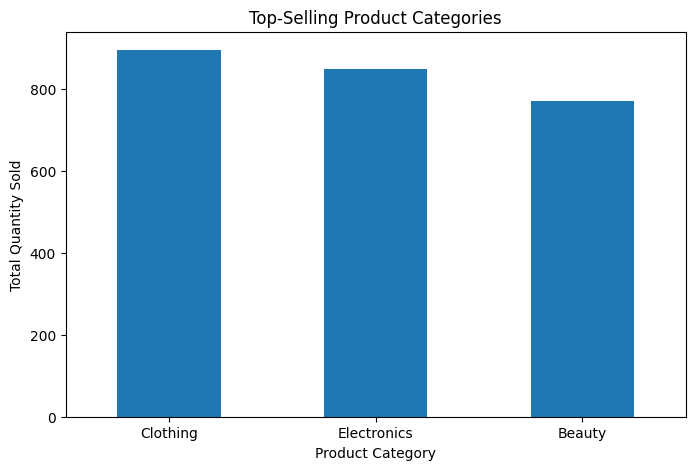

In [57]:
# Top-selling product categories by quantity sold

top_categories = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
top_categories.plot(kind='bar')

plt.title('Top-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()

### Observation

Clothing has the highest total quantity sold, followed by Electronics and Beauty. This indicates that Clothing has the strongest demand in terms of the number of units sold. Businesses can maintain sufficient stock of high-demand categories while using targeted promotions to improve sales of lower-performing categories.

In [58]:
top_categories.to_frame(name='Total Quantity Sold')

,Total Quantity Sold
Product Category,
Clothing,894
Electronics,849
Beauty,771


### Dataset Limitation

The dataset contains Product Category information but does not contain individual product names or product IDs. Therefore, a Top 10 individual products analysis cannot be performed. Instead, product categories were analyzed based on total quantity sold.

## Conclusion

The exploratory data analysis of the retail sales dataset provided useful insights into sales performance, customer demographics, product categories, and purchasing behaviour. The monthly and quarterly analysis showed that sales varied over time, with some periods performing better than others. The customer analysis showed a fairly balanced distribution between male and female customers, while the age-group analysis indicated that customers between 26 and 65 years form a major portion of the customer base.

Among the product categories, Clothing recorded the highest quantity sold, while Electronics generated slightly higher revenue than Clothing. The correlation analysis showed a strong positive relationship between Price per Unit and Total Amount, while Quantity also had a positive relationship with Total Amount. The average transaction analysis further showed differences in spending behaviour across age groups.

Overall, the analysis can help a retail business understand its customers, identify high-performing categories, and make better decisions regarding inventory, marketing, and sales strategies.

## Actionable Business Recommendations

1. **Maintain sufficient inventory for high-demand categories**
   
   Clothing recorded the highest quantity sold. The business should maintain adequate stock of Clothing products and monitor inventory regularly to reduce the risk of stock-outs during high-demand periods.

2. **Focus marketing efforts on high-revenue categories**
   
   Electronics generated the highest revenue among the categories. The business can promote Electronics through targeted offers, product bundles, and seasonal campaigns to increase revenue and customer purchases.

3. **Use customer demographics for targeted marketing**
   
   The analysis shows differences in customer distribution and average transaction amounts across age groups. The business should create age-specific promotions and product recommendations to better match customer preferences and improve customer engagement.